In [117]:
## need export cells and then run at res. 25, 50 & 100kb

In [118]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import os, subprocess

In [119]:
# Import python package for working with cooler files and tools for analysis
import cooler
import cooltools.lib.plotting

In [120]:
from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError("tutorials rely on cooltools version 0.5.4 or higher,"+
                         "please check your cooltools version and update to the latest")

In [121]:
### to load a cooler with a specific resolution use the following syntax:
#### this is the binsize used for eigs
clr_rbp1 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/50000")
clr_ctrl = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/50000")

In [122]:
import bioframe
bins = clr_ctrl.bins()[:]
hg38_genome = bioframe.load_fasta('/usr/users/papantonis1/aman/microc_project/refgen/hg38.fa');
## note the next command may require installing pysam
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
gc_cov.to_csv('hg38_gc_cov_50kb.tsv',index=False,sep='\t')
display(gc_cov)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/bioframe/extras.py:316: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("chrom", sort=False)[["start", "end"]].apply(_each)


,chrom,start,end,GC
0,chr1,0,50000,0.484250
1,chr1,50000,100000,0.376740
2,chr1,100000,150000,0.429960
3,chr1,150000,200000,0.486340
4,chr1,200000,250000,0.480564
...,...,...,...,...
61771,chrY,57050000,57100000,0.391180
61772,chrY,57100000,57150000,0.397320
61773,chrY,57150000,57200000,0.469440
61774,chrY,57200000,57227415,0.553775


In [123]:
view_df_ctrl = pd.DataFrame({'chrom': clr_ctrl.chromnames,
                        'start': 0,
                        'end': clr_ctrl.chromsizes.values,
                        'name': clr_ctrl.chromnames}
                      )

view_df_rbp1 = pd.DataFrame({'chrom': clr_rbp1.chromnames,
                        'start': 0,
                        'end': clr_rbp1.chromsizes.values,
                        'name': clr_rbp1.chromnames}
                      )

In [124]:
# obtain first 3 eigenvectors
cis_eigs_ctrl = cooltools.eigs_cis(
                        clr_ctrl,
                        gc_cov,
                        view_df=view_df_ctrl,
                        n_eigs=3,
                        )

cis_eigs_rbp1 = cooltools.eigs_cis(
                        clr_rbp1,
                        gc_cov,
                        view_df=view_df_rbp1,
                        n_eigs=3,
                        )

# cis_eigs[0] returns eigenvalues, here we focus on eigenvectors
eigenvector_track_ctrl = cis_eigs_ctrl[1][['chrom','start','end','E1']]
eigenvector_track_rbp1 = cis_eigs_rbp1[1][['chrom','start','end','E1']]

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):


In [125]:
cis_eigs_ctrl

(    chrom  start        end   name      eigval1     eigval2     eigval3
 0    chr1      0  248956422   chr1  2147.473851 -988.748086  956.190586
 1    chr2      0  242193529   chr2  2088.628518  882.062646  739.802050
 2    chr3      0  198295559   chr3  1693.651803  747.504629 -704.092129
 3    chr4      0  190214555   chr4  1423.653941  657.351965 -638.250007
 4    chr5      0  181538259   chr5  1373.143597  681.753512  630.288976
 5    chr6      0  170805979   chr6  1335.061811  619.022122 -520.387623
 6    chr7      0  159345973   chr7  1223.465132  562.463546  441.738494
 7    chr8      0  145138636   chr8  1428.045460  508.783075 -498.312160
 8    chr9      0  138394717   chr9  1025.703852  526.422280 -431.882677
 9   chr10      0  133797422  chr10  1032.485317  596.567239 -431.705236
 10  chr11      0  135086622  chr11  1277.393227  588.827536 -451.702970
 11  chr12      0  133275309  chr12  1171.593240  541.455679  471.694069
 12  chr13      0  114364328  chr13   783.239847  3

In [126]:
cis_eigs_ctrl[0]

,chrom,start,end,name,eigval1,eigval2,eigval3
0,chr1,0,248956422,chr1,2147.473851,-988.748086,956.190586
1,chr2,0,242193529,chr2,2088.628518,882.062646,739.802050
2,chr3,0,198295559,chr3,1693.651803,747.504629,-704.092129
3,chr4,0,190214555,chr4,1423.653941,657.351965,-638.250007
4,chr5,0,181538259,chr5,1373.143597,681.753512,630.288976
5,chr6,0,170805979,chr6,1335.061811,619.022122,-520.387623
6,chr7,0,159345973,chr7,1223.465132,562.463546,441.738494
7,chr8,0,145138636,chr8,1428.045460,508.783075,-498.312160
8,chr9,0,138394717,chr9,1025.703852,526.422280,-431.882677
9,chr10,0,133797422,chr10,1032.485317,596.567239,-431.705236


In [127]:
cis_eigs_ctrl[1]

,chrom,start,end,weight,E1,E2,E3
0,chr1,0,50000,NaN,NaN,NaN,NaN
1,chr1,50000,100000,NaN,NaN,NaN,NaN
2,chr1,100000,150000,NaN,NaN,NaN,NaN
3,chr1,150000,200000,NaN,NaN,NaN,NaN
4,chr1,200000,250000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
61771,chrY,57050000,57100000,NaN,NaN,NaN,NaN
61772,chrY,57100000,57150000,NaN,NaN,NaN,NaN
61773,chrY,57150000,57200000,NaN,NaN,NaN,NaN
61774,chrY,57200000,57227415,NaN,NaN,NaN,NaN


In [128]:
eigenvector_track_ctrl

,chrom,start,end,E1
0,chr1,0,50000,NaN
1,chr1,50000,100000,NaN
2,chr1,100000,150000,NaN
3,chr1,150000,200000,NaN
4,chr1,200000,250000,NaN
...,...,...,...,...
61771,chrY,57050000,57100000,NaN
61772,chrY,57100000,57150000,NaN
61773,chrY,57150000,57200000,NaN
61774,chrY,57200000,57227415,NaN


In [129]:
eigenvector_track_rbp1

,chrom,start,end,E1
0,chr1,0,50000,NaN
1,chr1,50000,100000,NaN
2,chr1,100000,150000,NaN
3,chr1,150000,200000,NaN
4,chr1,200000,250000,NaN
...,...,...,...,...
61771,chrY,57050000,57100000,NaN
61772,chrY,57100000,57150000,NaN
61773,chrY,57150000,57200000,NaN
61774,chrY,57200000,57227415,NaN


In [130]:
# function to count compartments
def count_compartments(eigen_df):
    df = eigen_df.dropna(subset=['E1']).copy() # dropping nans
    df['compartment'] = df['E1'].apply(lambda x: 1 if x > 0 else -1) # lambda func. to assign compartment label: +1 for A, -1 for B
    # Detect compartment boundaries (change in sign)
    df['comp_change'] = (df['compartment'] != df['compartment'].shift(1)).astype(int)
    # Count the number of transitions (start of new compartments)
    n_compartments = df['comp_change'].sum()
    return n_compartments

In [131]:
n_ctrl = count_compartments(eigenvector_track_ctrl)
n_rbp1 = count_compartments(eigenvector_track_rbp1)

print(f"CTRL: {n_ctrl} compartments")
print(f"RBP1: {n_rbp1} compartments")

CTRL: 3087 compartments
RBP1: 3181 compartments


In [132]:
# function to get the counts of A & B comps. seperate
def count_A_B_compartments(eigen_df):
    df = eigen_df.dropna(subset=['E1']).copy()
    df['compartment'] = df['E1'].apply(lambda x: 1 if x > 0 else -1)
    df['comp_change'] = (df['compartment'] != df['compartment'].shift(1)).astype(int)
    df['comp_group'] = df['comp_change'].cumsum()

    # For each group of contiguous bins, take one compartment label
    comp_counts = df.groupby('comp_group')['compartment'].first().value_counts()

    n_A = comp_counts.get(1, 0)
    n_B = comp_counts.get(-1, 0)

    return n_A, n_B

In [133]:
n_A_ctrl, n_B_ctrl = count_A_B_compartments(eigenvector_track_ctrl)
n_A_rbp1, n_B_rbp1 = count_A_B_compartments(eigenvector_track_rbp1)

print(f"CTRL - A: {n_A_ctrl}, B: {n_B_ctrl}")
print(f"RBP1 - A: {n_A_rbp1}, B: {n_B_rbp1}")

CTRL - A: 1544, B: 1543
RBP1 - A: 1591, B: 1590


In [134]:
# Merge CTRL and RBP1 eigenvectors by genomic bin
eigen_merged = pd.merge(
    eigenvector_track_ctrl,
    eigenvector_track_rbp1,
    on=['chrom', 'start', 'end'],
    suffixes=('_CTRL', '_RBP1')
)


Pearson r = 0.987, p = 0.00e+00


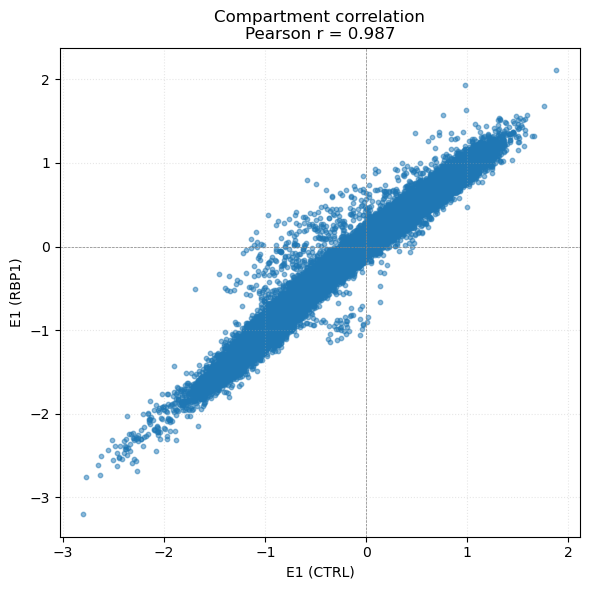

In [135]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Ensure clean matched E1 vectors
eigen_clean = eigen_merged.dropna(subset=['E1_CTRL', 'E1_RBP1'])
E1_ctrl = eigen_clean['E1_CTRL'].values
E1_rbp1 = eigen_clean['E1_RBP1'].values

# Pearson correlation
r_value, p_value = pearsonr(E1_ctrl, E1_rbp1)
print(f"Pearson r = {r_value:.3f}, p = {p_value:.2e}")

# Scatterplot
plt.figure(figsize=(6,6))
plt.scatter(E1_ctrl, E1_rbp1, alpha=0.5, s=10)
plt.xlabel("E1 (CTRL)")
plt.ylabel("E1 (RBP1)")
plt.title(f"Compartment correlation\nPearson r = {r_value:.3f}")
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

In [136]:
# Merging PC1 from control and eed
merged_pc1 = eigenvector_track_ctrl.merge(
    eigenvector_track_rbp1,
    on=['chrom', 'start', 'end'],
    suffixes=('_ctrl', '_rbp1')
)

In [137]:
merged_pc1

,chrom,start,end,E1_ctrl,E1_rbp1
0,chr1,0,50000,NaN,NaN
1,chr1,50000,100000,NaN,NaN
2,chr1,100000,150000,NaN,NaN
3,chr1,150000,200000,NaN,NaN
4,chr1,200000,250000,NaN,NaN
...,...,...,...,...,...
61771,chrY,57050000,57100000,NaN,NaN
61772,chrY,57100000,57150000,NaN,NaN
61773,chrY,57150000,57200000,NaN,NaN
61774,chrY,57200000,57227415,NaN,NaN


In [138]:
merged_pc1.describe()

,start,end,E1_ctrl,E1_rbp1
count,6.177600e+04,6.177600e+04,54704.000000,54971.000000
mean,7.676535e+07,7.681534e+07,-0.090693,-0.072708
std,5.492642e+07,5.492642e+07,0.670613,0.671993
min,0.000000e+00,1.656900e+04,-2.799922,-3.205480
25%,3.215000e+07,3.220000e+07,-0.644884,-0.587649
50%,6.665000e+07,6.670000e+07,-0.056446,0.000822
75%,1.125000e+08,1.125500e+08,0.484597,0.488621
max,2.489500e+08,2.489564e+08,1.881481,2.111608


In [139]:
# delta PC1
merged_pc1['delta_pc1'] = merged_pc1['E1_rbp1'] - merged_pc1['E1_ctrl']

In [140]:
merged_pc1

,chrom,start,end,E1_ctrl,E1_rbp1,delta_pc1
0,chr1,0,50000,NaN,NaN,NaN
1,chr1,50000,100000,NaN,NaN,NaN
2,chr1,100000,150000,NaN,NaN,NaN
3,chr1,150000,200000,NaN,NaN,NaN
4,chr1,200000,250000,NaN,NaN,NaN
...,...,...,...,...,...,...
61771,chrY,57050000,57100000,NaN,NaN,NaN
61772,chrY,57100000,57150000,NaN,NaN,NaN
61773,chrY,57150000,57200000,NaN,NaN,NaN
61774,chrY,57200000,57227415,NaN,NaN,NaN


In [141]:
# Classify compartment switches
#merged_pc1['compartment_switch'] = 'stable'
#merged_pc1.loc[merged_pc1['delta_pc1'] > 0.4, 'compartment_switch'] = 'B_to_A'
#merged_pc1.loc[merged_pc1['delta_pc1'] < -0.4, 'compartment_switch'] = 'A_to_B'

In [142]:
valid = merged_pc1['delta_pc1'].notna()
merged_pc1.loc[valid, 'compartment_switch'] = 'stable'
merged_pc1.loc[valid & (merged_pc1['delta_pc1'] > 0.4), 'compartment_switch'] = 'B_to_A'
merged_pc1.loc[valid & (merged_pc1['delta_pc1'] < -0.4), 'compartment_switch'] = 'A_to_B'

In [143]:
merged_pc1

,chrom,start,end,E1_ctrl,E1_rbp1,delta_pc1,compartment_switch
0,chr1,0,50000,NaN,NaN,NaN,NaN
1,chr1,50000,100000,NaN,NaN,NaN,NaN
2,chr1,100000,150000,NaN,NaN,NaN,NaN
3,chr1,150000,200000,NaN,NaN,NaN,NaN
4,chr1,200000,250000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
61771,chrY,57050000,57100000,NaN,NaN,NaN,NaN
61772,chrY,57100000,57150000,NaN,NaN,NaN,NaN
61773,chrY,57150000,57200000,NaN,NaN,NaN,NaN
61774,chrY,57200000,57227415,NaN,NaN,NaN,NaN


In [181]:
merged_pc1[~merged_pc1["compartment_switch"].isna()]

,chrom,start,end,E1_ctrl,E1_rbp1,delta_pc1,compartment_switch
59,chr1,2950000,3000000,0.998402,0.880686,-0.117716,stable
60,chr1,3000000,3050000,0.957555,0.954645,-0.002910,stable
68,chr1,3400000,3450000,0.826976,0.731243,-0.095733,stable
75,chr1,3750000,3800000,1.320639,1.232400,-0.088239,stable
76,chr1,3800000,3850000,1.026703,1.097310,0.070607,stable
...,...,...,...,...,...,...,...
61162,chrY,26600000,26650000,-1.169656,-1.564277,-0.394621,stable
61163,chrY,26650000,26700000,-1.646187,-1.755096,-0.108909,stable
61764,chrY,56700000,56750000,-1.901487,-1.734703,0.166784,stable
61766,chrY,56800000,56850000,0.686387,0.587526,-0.098861,stable


In [144]:
#merged_pc1.query("compartment_switch == 'B_to_A'")

In [145]:
#merged_pc1.query("compartment_switch == 'A_to_B'")

In [146]:
#cols = ['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']
#all_loops = pd.read_csv("all_loops_signal_log2fc.bedpe", usecols=cols)
all_loops = pd.read_csv("all_loops_signal_log2fc.bedpe")

In [147]:
all_loops # ctrl + eed

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped
0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,0.000000,0.000000
1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,0.000000,0.000000
2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,0.000000,0.000000
3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000
4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,0.061177,0.061177
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,-0.570544,-0.570544
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,0.005836,0.005836
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,0.502513,0.502513


In [148]:
def label_condition(status):
    if status == 'gained':
        return 'Mutant loop'
    elif status == 'lost':
        return 'Control loop'
    else:
        return 'shared'

all_loops['condition'] = all_loops['status'].apply(label_condition)
all_loops

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition
0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,0.000000,0.000000,shared
1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,0.000000,0.000000,shared
2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,0.000000,0.000000,shared
3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared
4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared
...,...,...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,0.061177,0.061177,Mutant loop
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,-0.570544,-0.570544,Mutant loop
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,0.005836,0.005836,Mutant loop
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,0.502513,0.502513,Mutant loop


In [149]:
all_loops.describe()

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,start1,end1,start2,end2,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped
count,3.227700e+04,3.227700e+04,3.227700e+04,3.227700e+04,31649.000000,31703.000000,3.227700e+04,32277.000000
mean,8.162121e+07,8.162621e+07,8.200365e+07,8.200865e+07,0.014878,0.014441,NaN,-0.034962
std,5.648699e+07,5.648699e+07,5.649696e+07,5.649696e+07,0.011333,0.010752,NaN,0.661933
min,3.500000e+04,4.000000e+04,1.200000e+05,1.250000e+05,0.000000,0.000000,-inf,-5.000000
25%,3.630000e+07,3.630500e+07,3.666250e+07,3.666750e+07,0.007374,0.007135,-3.290217e-01,-0.329022
50%,7.093250e+07,7.093750e+07,7.151000e+07,7.151500e+07,0.012010,0.011774,-2.961025e-02,-0.029610
75%,1.174525e+08,1.174575e+08,1.178325e+08,1.178375e+08,0.019028,0.018614,2.496541e-01,0.249654
max,2.487000e+08,2.487050e+08,2.488050e+08,2.488100e+08,0.367866,0.275419,inf,5.000000


In [150]:
# giving loop index and adding anchor id # A1 = left ## A2 = right anchor
anchor1 = all_loops[['chr1','start1','end1', 'condition']].copy()
anchor1.columns = ['chrom','start','end', 'condition']
anchor1['anchor'] = 'A1'
anchor1['loop_id'] = anchor1.index
anchor1

,chrom,start,end,condition,anchor,loop_id
0,chr1,1952500,1957500,shared,A1,0
1,chr1,2202500,2207500,shared,A1,1
2,chr1,2412500,2417500,shared,A1,2
3,chr1,3490000,3495000,shared,A1,3
4,chr1,3565000,3570000,shared,A1,4
...,...,...,...,...,...,...
32272,chrY,10945000,10950000,Mutant loop,A1,32272
32273,chrY,10982500,10987500,Mutant loop,A1,32273
32274,chrY,11292500,11297500,Mutant loop,A1,32274
32275,chrY,11530000,11535000,Mutant loop,A1,32275


In [151]:
# giving loop index and adding anchor id
anchor2 = all_loops[['chr2','start2','end2', 'condition']].copy()
anchor2.columns = ['chrom','start','end', 'condition']
anchor2['anchor'] = 'A2'
anchor2['loop_id'] = anchor2.index
anchor2

,chrom,start,end,condition,anchor,loop_id
0,chr1,2042500,2047500,shared,A2,0
1,chr1,2382500,2387500,shared,A2,1
2,chr1,2552500,2557500,shared,A2,2
3,chr1,3615000,3620000,shared,A2,3
4,chr1,3615000,3620000,shared,A2,4
...,...,...,...,...,...,...
32272,chrY,11290000,11295000,Mutant loop,A2,32272
32273,chrY,11292500,11297500,Mutant loop,A2,32273
32274,chrY,11722500,11727500,Mutant loop,A2,32274
32275,chrY,11760000,11765000,Mutant loop,A2,32275


In [152]:
all_anchors = pd.concat([anchor1, anchor2], ignore_index=True) # merge
all_anchors

,chrom,start,end,condition,anchor,loop_id
0,chr1,1952500,1957500,shared,A1,0
1,chr1,2202500,2207500,shared,A1,1
2,chr1,2412500,2417500,shared,A1,2
3,chr1,3490000,3495000,shared,A1,3
4,chr1,3565000,3570000,shared,A1,4
...,...,...,...,...,...,...
64549,chrY,11290000,11295000,Mutant loop,A2,32272
64550,chrY,11292500,11297500,Mutant loop,A2,32273
64551,chrY,11722500,11727500,Mutant loop,A2,32274
64552,chrY,11760000,11765000,Mutant loop,A2,32275


In [153]:
merged_pc1

,chrom,start,end,E1_ctrl,E1_rbp1,delta_pc1,compartment_switch
0,chr1,0,50000,NaN,NaN,NaN,NaN
1,chr1,50000,100000,NaN,NaN,NaN,NaN
2,chr1,100000,150000,NaN,NaN,NaN,NaN
3,chr1,150000,200000,NaN,NaN,NaN,NaN
4,chr1,200000,250000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
61771,chrY,57050000,57100000,NaN,NaN,NaN,NaN
61772,chrY,57100000,57150000,NaN,NaN,NaN,NaN
61773,chrY,57150000,57200000,NaN,NaN,NaN,NaN
61774,chrY,57200000,57227415,NaN,NaN,NaN,NaN


In [154]:
# renaming neeeded
all_anchors = all_anchors.rename(columns={
    'chrom': 'Chromosome',
    'start': 'Start',
    'end': 'End'
})

merged_pc1_renamed = merged_pc1.rename(columns={
    'chrom': 'Chromosome',
    'start': 'Start',
    'end': 'End'
})

In [155]:
all_anchors

,Chromosome,Start,End,condition,anchor,loop_id
0,chr1,1952500,1957500,shared,A1,0
1,chr1,2202500,2207500,shared,A1,1
2,chr1,2412500,2417500,shared,A1,2
3,chr1,3490000,3495000,shared,A1,3
4,chr1,3565000,3570000,shared,A1,4
...,...,...,...,...,...,...
64549,chrY,11290000,11295000,Mutant loop,A2,32272
64550,chrY,11292500,11297500,Mutant loop,A2,32273
64551,chrY,11722500,11727500,Mutant loop,A2,32274
64552,chrY,11760000,11765000,Mutant loop,A2,32275


In [156]:
# mapping to compartment switch
import pyranges as pr # put at top

anchors_pr = pr.PyRanges(all_anchors)
compartments_pr = pr.PyRanges(merged_pc1_renamed[['Chromosome','Start','End','compartment_switch']])
annotated = anchors_pr.nearest(compartments_pr).df # nearest() chosen instead of join
annotated # here along with loop id either a `signal`  column or ìdentifier to cnnct back

#annotated is the tester and needs to be exported as a csv
## Similarly for TADs and Stripes

,Chromosome,Start,End,condition,anchor,loop_id,Start_b,End_b,compartment_switch,Distance
0,chr1,1952500,1957500,shared,A1,0,1950000,2000000,NaN,0
1,chr1,2202500,2207500,shared,A1,1,2200000,2250000,NaN,0
2,chr1,2412500,2417500,shared,A1,2,2400000,2450000,NaN,0
3,chr1,3490000,3495000,shared,A1,3,3450000,3500000,NaN,0
4,chr1,3565000,3570000,shared,A1,4,3550000,3600000,NaN,0
...,...,...,...,...,...,...,...,...,...,...
64549,chrY,11290000,11295000,Mutant loop,A2,32272,11250000,11300000,stable,0
64550,chrY,11292500,11297500,Mutant loop,A2,32273,11250000,11300000,stable,0
64551,chrY,11722500,11727500,Mutant loop,A2,32274,11700000,11750000,stable,0
64552,chrY,11760000,11765000,Mutant loop,A2,32275,11750000,11800000,stable,0


In [182]:
annotated[~annotated["compartment_switch"].isna()]

,Chromosome,Start,End,condition,anchor,loop_id,Start_b,End_b,compartment_switch,Distance
5,chr1,3912500,3917500,shared,A1,5,3900000,3950000,stable,0
6,chr1,4092500,4097500,shared,A1,6,4050000,4100000,stable,0
7,chr1,5502500,5507500,shared,A1,7,5500000,5550000,stable,0
11,chr1,6720000,6725000,shared,A1,11,6700000,6750000,stable,0
12,chr1,7032500,7037500,shared,A1,12,7000000,7050000,stable,0
...,...,...,...,...,...,...,...,...,...,...
64549,chrY,11290000,11295000,Mutant loop,A2,32272,11250000,11300000,stable,0
64550,chrY,11292500,11297500,Mutant loop,A2,32273,11250000,11300000,stable,0
64551,chrY,11722500,11727500,Mutant loop,A2,32274,11700000,11750000,stable,0
64552,chrY,11760000,11765000,Mutant loop,A2,32275,11750000,11800000,stable,0


In [157]:
# anchorlvl to loop lvl
loopwise = annotated.pivot(index='loop_id', columns='anchor', values='compartment_switch').reset_index()
loopwise.columns.name = None
loopwise = loopwise.merge(all_loops[['condition']], left_on='loop_id', right_index=True)

def classify_loop_type(row):
    if row['condition'] in ['shared', 'Mutant loop']:
        if pd.isnull(row['A1']) or pd.isnull(row['A2']):
            return 'unknown'
        return f"{row['A1']}_{row['A2']}"
    elif row['condition'] == 'Control loop':
        if pd.isnull(row['A1']) or pd.isnull(row['A2']):
            return 'unknown'
        return 'stable_stable'


loopwise['loop_type'] = loopwise.apply(classify_loop_type, axis=1)


In [158]:
loopwise['loop_type'].value_counts() # would be nice to have identifier to know ctrl or eed # check above
#loopwise.groupby('condition')['loop_type'].value_counts()
## how to have this??

loop_type
stable_stable    31414
unknown            740
B_to_A_B_to_A       69
B_to_A_stable       24
stable_B_to_A       22
A_to_B_stable        5
stable_A_to_B        2
A_to_B_A_to_B        1
Name: count, dtype: int64

In [159]:
loopwise.groupby('condition')['loop_type'].value_counts()

condition     loop_type    
Control loop  stable_stable    11314
              unknown            268
Mutant loop   stable_stable    12915
              unknown            252
              B_to_A_B_to_A       45
              stable_B_to_A       12
              B_to_A_stable       11
              A_to_B_stable        3
              stable_A_to_B        2
              A_to_B_A_to_B        1
shared        stable_stable     7185
              unknown            220
              B_to_A_B_to_A       24
              B_to_A_stable       13
              stable_B_to_A       10
              A_to_B_stable        2
Name: count, dtype: int64

In [160]:
loopwise

,loop_id,A1,A2,condition,loop_type
0,0,NaN,NaN,shared,unknown
1,1,NaN,NaN,shared,unknown
2,2,NaN,NaN,shared,unknown
3,3,NaN,NaN,shared,unknown
4,4,NaN,NaN,shared,unknown
...,...,...,...,...,...
32272,32272,stable,stable,Mutant loop,stable_stable
32273,32273,stable,stable,Mutant loop,stable_stable
32274,32274,stable,stable,Mutant loop,stable_stable
32275,32275,stable,stable,Mutant loop,stable_stable


In [161]:
pd.set_option('display.max_rows', None)

In [162]:
loopwise[loopwise['loop_type'].isin(['B_to_A_B_to_A', 'B_to_A_stable', 'stable_B_to_A'])]

,loop_id,A1,A2,condition,loop_type
4178,4178,B_to_A,B_to_A,shared,B_to_A_B_to_A
4179,4179,B_to_A,B_to_A,shared,B_to_A_B_to_A
4180,4180,B_to_A,B_to_A,shared,B_to_A_B_to_A
4182,4182,stable,B_to_A,shared,stable_B_to_A
4183,4183,stable,B_to_A,shared,stable_B_to_A
4185,4185,B_to_A,B_to_A,shared,B_to_A_B_to_A
4186,4186,B_to_A,stable,shared,B_to_A_stable
4187,4187,B_to_A,stable,shared,B_to_A_stable
4189,4189,B_to_A,B_to_A,shared,B_to_A_B_to_A
4193,4193,B_to_A,stable,shared,B_to_A_stable


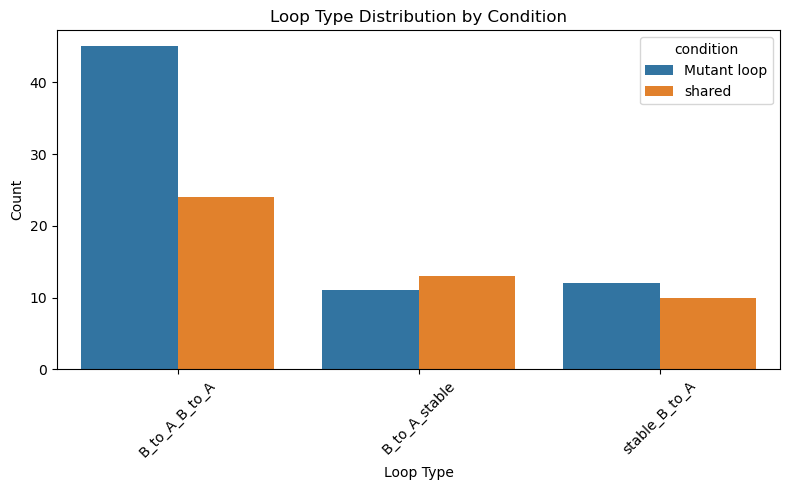

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for selected loop types
selected_types = ['B_to_A_B_to_A', 'B_to_A_stable', 'stable_B_to_A']
filtered = loopwise[loopwise['loop_type'].isin(selected_types)]

# Count combinations of loop_type and condition
group_counts = filtered.groupby(['loop_type', 'condition']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=group_counts, x='loop_type', y='count', hue='condition')
plt.xlabel('Loop Type')
plt.ylabel('Count')
plt.title('Loop Type Distribution by Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [164]:
# Group by condition and loop_type, then count
loopwise.groupby(['condition', 'loop_type']).size().unstack(fill_value=0)

loop_type,A_to_B_A_to_B,A_to_B_stable,B_to_A_B_to_A,B_to_A_stable,stable_A_to_B,stable_B_to_A,stable_stable,unknown
condition,,,,,,,,
Control loop,0,0,0,0,0,0,11314,268
Mutant loop,1,3,45,11,2,12,12915,252
shared,0,2,24,13,0,10,7185,220


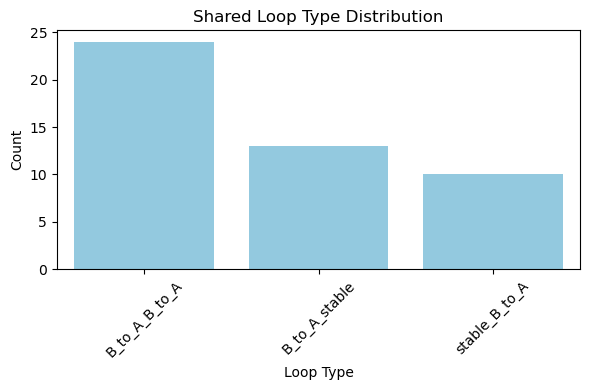

In [165]:
# Filter only shared loops
shared_only = group_counts[group_counts['condition'] == 'shared']

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=shared_only, x='loop_type', y='count', color='skyblue')
plt.xlabel('Loop Type')
plt.ylabel('Count')
plt.title('Shared Loop Type Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [166]:
subset = loopwise[loopwise['loop_type'].isin(['B_to_A_B_to_A', 'B_to_A_stable', 'stable_B_to_A'])]
subset['condition'].value_counts()

condition
Mutant loop    68
shared         47
Name: count, dtype: int64

In [167]:
pd.reset_option('display.max_rows')

In [168]:
all_loops['distance'] = abs(all_loops['start2'] - all_loops['start1'])
all_loops['distance'].describe()

# here maybe classify as long and short loops using a threshold

count    3.227700e+04
mean     3.824338e+05
std      3.843100e+05
min      3.000000e+04
25%      1.400000e+05
50%      2.700000e+05
75%      5.000000e+05
max      9.570000e+06
Name: distance, dtype: float64

In [169]:
annotated['compartment_switch'].value_counts() # this is different from above which was for two of the loop anchors

compartment_switch
stable    63180
B_to_A      284
A_to_B       24
Name: count, dtype: int64

#### Different approach

merged_pc1

merged_pc1['Chromosome'] = merged_pc1['chrom']
merged_pc1['Start'] = merged_pc1['start']
merged_pc1['End'] = merged_pc1['end']

compartments_pr = pr.PyRanges(merged_pc1[['Chromosome', 'Start', 'End', 'delta_pc1']])
anchors_pr = pr.PyRanges(all_anchors[['Chromosome', 'Start', 'End', 'loop_id', 'anchor']])
annotated = anchors_pr.nearest(compartments_pr).df

loopwise = annotated.pivot(index='loop_id', columns='anchor', values='delta_pc1').reset_index()
loopwise.columns.name = None
loopwise['loop_delta'] = loopwise['A1'] + loopwise['A2']

loopwise

import seaborn as sns
loopwise['delta_diff'] = loopwise['A1'] - loopwise['A2']
sns.histplot(loopwise['delta_diff'], bins=100, kde=True)

In [170]:
#sns.jointplot(data=loopwise, x='A1', y='A2', kind='hex')

In [171]:
clr_ctrl.binsize

50000

----

In [172]:
annotated

,Chromosome,Start,End,condition,anchor,loop_id,Start_b,End_b,compartment_switch,Distance
0,chr1,1952500,1957500,shared,A1,0,1950000,2000000,NaN,0
1,chr1,2202500,2207500,shared,A1,1,2200000,2250000,NaN,0
2,chr1,2412500,2417500,shared,A1,2,2400000,2450000,NaN,0
3,chr1,3490000,3495000,shared,A1,3,3450000,3500000,NaN,0
4,chr1,3565000,3570000,shared,A1,4,3550000,3600000,NaN,0
...,...,...,...,...,...,...,...,...,...,...
64549,chrY,11290000,11295000,Mutant loop,A2,32272,11250000,11300000,stable,0
64550,chrY,11292500,11297500,Mutant loop,A2,32273,11250000,11300000,stable,0
64551,chrY,11722500,11727500,Mutant loop,A2,32274,11700000,11750000,stable,0
64552,chrY,11760000,11765000,Mutant loop,A2,32275,11750000,11800000,stable,0


In [173]:
pivoted = annotated.pivot(index='loop_id', columns='anchor', values='compartment_switch')
pivoted.columns = ['comp_switch_A1', 'comp_switch_A2']
pivoted = pivoted.reset_index()
pivoted

,loop_id,comp_switch_A1,comp_switch_A2
0,0,NaN,NaN
1,1,NaN,NaN
2,2,NaN,NaN
3,3,NaN,NaN
4,4,NaN,NaN
...,...,...,...
32272,32272,stable,stable
32273,32273,stable,stable
32274,32274,stable,stable
32275,32275,stable,stable


In [174]:
all_loops

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance
0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,0.000000,0.000000,shared,90000
1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,0.000000,0.000000,shared,180000
2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,0.000000,0.000000,shared,140000
3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,125000
4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,50000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,0.061177,0.061177,Mutant loop,345000
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,-0.570544,-0.570544,Mutant loop,310000
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,0.005836,0.005836,Mutant loop,430000
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,0.502513,0.502513,Mutant loop,230000


In [175]:
# Ensure 'loop_id' is a column in both DataFrames
pivoted = pivoted.copy()
if 'loop_id' not in pivoted.columns:
    pivoted['loop_id'] = pivoted.index
    pivoted = pivoted.reset_index(drop=True)

all_loops = all_loops.copy()
if 'loop_id' not in all_loops.columns:
    all_loops['loop_id'] = all_loops.index
    all_loops = all_loops.reset_index(drop=True)

# Merge
merged = all_loops.merge(pivoted, on='loop_id', how='left')


In [176]:
merged

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2
0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,0.000000,0.000000,shared,90000,0,NaN,NaN
1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,0.000000,0.000000,shared,180000,1,NaN,NaN
2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,0.000000,0.000000,shared,140000,2,NaN,NaN
3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,125000,3,NaN,NaN
4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000,shared,50000,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,0.061177,0.061177,Mutant loop,345000,32272,stable,stable
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,-0.570544,-0.570544,Mutant loop,310000,32273,stable,stable
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,0.005836,0.005836,Mutant loop,430000,32274,stable,stable
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,0.502513,0.502513,Mutant loop,230000,32275,stable,stable


In [177]:
# Find rows where both signals are non-zero
both_present = merged[(merged['ctrl_signal'] > 0) & (merged['rbp1_signal'] > 0)]

# Show how many such rows exist
print(f"Loops with both signals present: {len(both_present)}")
display(both_present.head())

Loops with both signals present: 31569


,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped,condition,distance,loop_id,comp_switch_A1,comp_switch_A2
5,chr1,3912500,3917500,chr1,4822500,4827500,shared,0.006495,0.007785,0.261285,0.261285,shared,910000,5,stable,stable
6,chr1,4092500,4097500,chr1,5602500,5607500,shared,0.006672,0.006946,0.058027,0.058027,shared,1510000,6,stable,stable
7,chr1,5502500,5507500,chr1,5622500,5627500,shared,0.020849,0.018260,-0.191275,-0.191275,shared,120000,7,stable,stable
9,chr1,6252500,6257500,chr1,6332500,6337500,shared,0.044799,0.033716,-0.410037,-0.410037,shared,80000,9,NaN,stable
10,chr1,6355000,6360000,chr1,6400000,6405000,shared,0.062567,0.043755,-0.515945,-0.515945,shared,45000,10,NaN,NaN


In [178]:
# Loops with only ctrl_signal
only_ctrl = merged[(merged['ctrl_signal'] > 0) & ((merged['rbp1_signal'].isna()) | (merged['rbp1_signal'] == 0))]

# Loops with only rbp1_signal
only_rbp1 = merged[(merged['rbp1_signal'] > 0) & ((merged['ctrl_signal'].isna()) | (merged['ctrl_signal'] == 0))]

# Print counts
print(f"Only ctrl_signal present: {len(only_ctrl)}")
print(f"Only rbp1_signal present: {len(only_rbp1)}")


Only ctrl_signal present: 66
Only rbp1_signal present: 118


In [179]:
merged['condition'].value_counts()

condition
Mutant loop     13241
Control loop    11582
shared           7454
Name: count, dtype: int64